240000


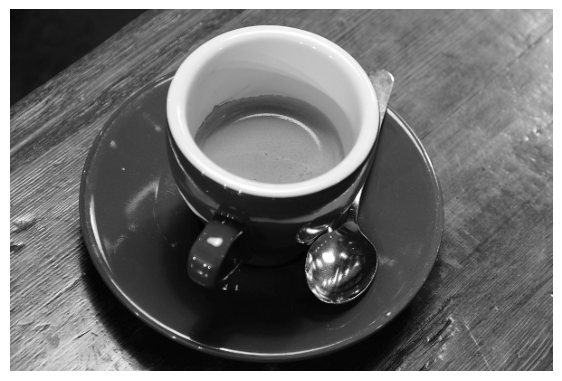

In [17]:
import skimage as si
import skimage.color as sc
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as ss
from algorithms import Algorithms
import time
import pywt

img = sc.rgb2gray( si.data.coffee() )

print( np.prod( img.shape ) )

plt.figure( figsize = ( 7, 7 ) )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [18]:
N_kernel = 7
kernel = np.full( ( N_kernel, N_kernel ), 1 / ( N_kernel ** 2 ) )

def A( x ):
    return ss.convolve2d( x, kernel, mode = "same" )

def A_transpose( x ):
    return ss.correlate2d( x, kernel, mode = "same" )

def ATA( x ):
    return A_transpose( A( x ) )

In [19]:
#testando se AT é adjunta de A ( y'Ax = x'ATy )

x = np.random.standard_normal( size = img.shape )
y = np.random.standard_normal( size = img.shape )

print( ( y * A( x ) ).sum() )
print( ( x * A_transpose( y ) ).sum() )

#okay

-21.675585381668352
-21.675585381668363


In [20]:
img_borrada = A( img )


In [21]:
#vendo se H é adjunta de HT (y'Hx = x'HTy) e se HT é a inversa de H

def H( x, wavelet = 'db5' ):
  return pywt.coeffs_to_array( pywt.wavedec2( x, wavelet = wavelet, mode = 'periodization' ) )

def HT( c, wavelet = 'db5' ):
  return pywt.waverec2( pywt.array_to_coeffs( *c, output_format = 'wavedec2' ), wavelet = wavelet, mode = 'periodization' )

Hx = H( x )

print( np.sum( y * Hx[ 0 ] ) )
print( np.sum( x * HT( ( y, Hx[ 1 ] ) ) ) )

#para a imagem do café tem esse problema de que o pywt expande o tamanho da imagem, com isso H não é adjunta de HT ( encontrado o problema )

ValueError: operands could not be broadcast together with shapes (400,600) (401,601) 

In [ ]:
#imagem borrada com ruído
gauss_noise = np.random.normal( 0, 0.01, img.shape )
b = img_borrada + gauss_noise

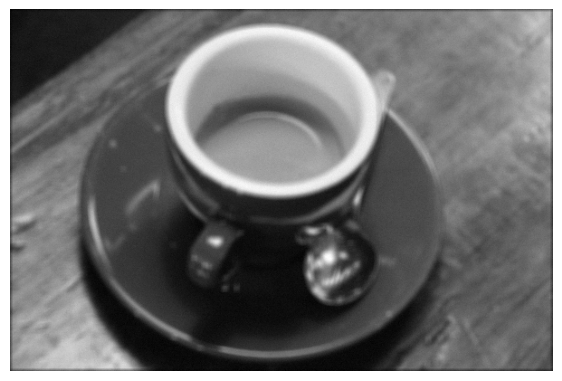

In [ ]:
plt.figure( figsize = ( 7, 7 ) )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [ ]:
def f( x ):
    return 1/2 * ( (A( x ) - b) ** 2 ).sum()

def grad_f( x ):
    return A_transpose( A( x ) - b )

def g( x, wavelet = 'haar' ):
  coeffs = pywt.wavedec2( x, wavelet = wavelet, mode = 'periodization' )
  l1 = 0.0
  for i in coeffs[ 1: ]:#to descartando [ LL, (LH1, HL1, HH1), ( LH2, HL2, HH2 ), ... ] o primeiro
    for j in i:#iterando dentro de cada tupla
      l1 += np.sum( np.abs( j ) )
  return l1

In [ ]:
#parametros não estão bem ajustados ainda
step = 0.8
gamma = 0.1
x0 = np.zeros_like( b )
wav = 'db5'
prox = Algorithms.prox_wavelet

In [ ]:
iters_ista_fixo = Algorithms.ista_fixo( f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, tol = 1.0e-2, wavelet = wav )

In [ ]:
iters_fista_fixo = Algorithms.fista_fixo( f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, tol = 1.0e-2, wavelet = wav )

In [ ]:
iters_ista_exato =  Algorithms.ista_exato( Q = ATA ,f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, tol = 1.0e-2, wavelet = wav )

In [ ]:
iters_fista_exato =  Algorithms.fista_exato( Q = ATA ,f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, tol = 1.0e-2, wavelet = wav )
#note que o fista com o tamanho de passo calculado exato não parece estar convergindo, (pode ser pq step > 1/L talvez?)
#fiz alguns testes deixando o step = 1.4 para todos os algoritmos, no ISTA converge, no FISTA não converge)

O tamanho do passo calculado foi de: 1.0112446656193477
O tamanho do passo calculado foi de: 1.3465911852795283
O tamanho do passo calculado foi de: 1.340240150114035
O tamanho do passo calculado foi de: 1.3381680823480815
O tamanho do passo calculado foi de: 1.3371492796829565
O tamanho do passo calculado foi de: 1.3365501613648139
O tamanho do passo calculado foi de: 1.3361597804598266
O tamanho do passo calculado foi de: 1.335887850889923
O tamanho do passo calculado foi de: 1.3356892942523177
O tamanho do passo calculado foi de: 1.335539095016517
O tamanho do passo calculado foi de: 1.3354222573764223
O tamanho do passo calculado foi de: 1.335329250645785
O tamanho do passo calculado foi de: 1.335253736960643
O tamanho do passo calculado foi de: 1.3351913490086902
O tamanho do passo calculado foi de: 1.335138990962856
O tamanho do passo calculado foi de: 1.335094417709509
O tamanho do passo calculado foi de: 1.3350559704745404
O tamanho do passo calculado foi de: 1.3350224045885861

Text(0.5, 1.0, 'FISTA Exato')

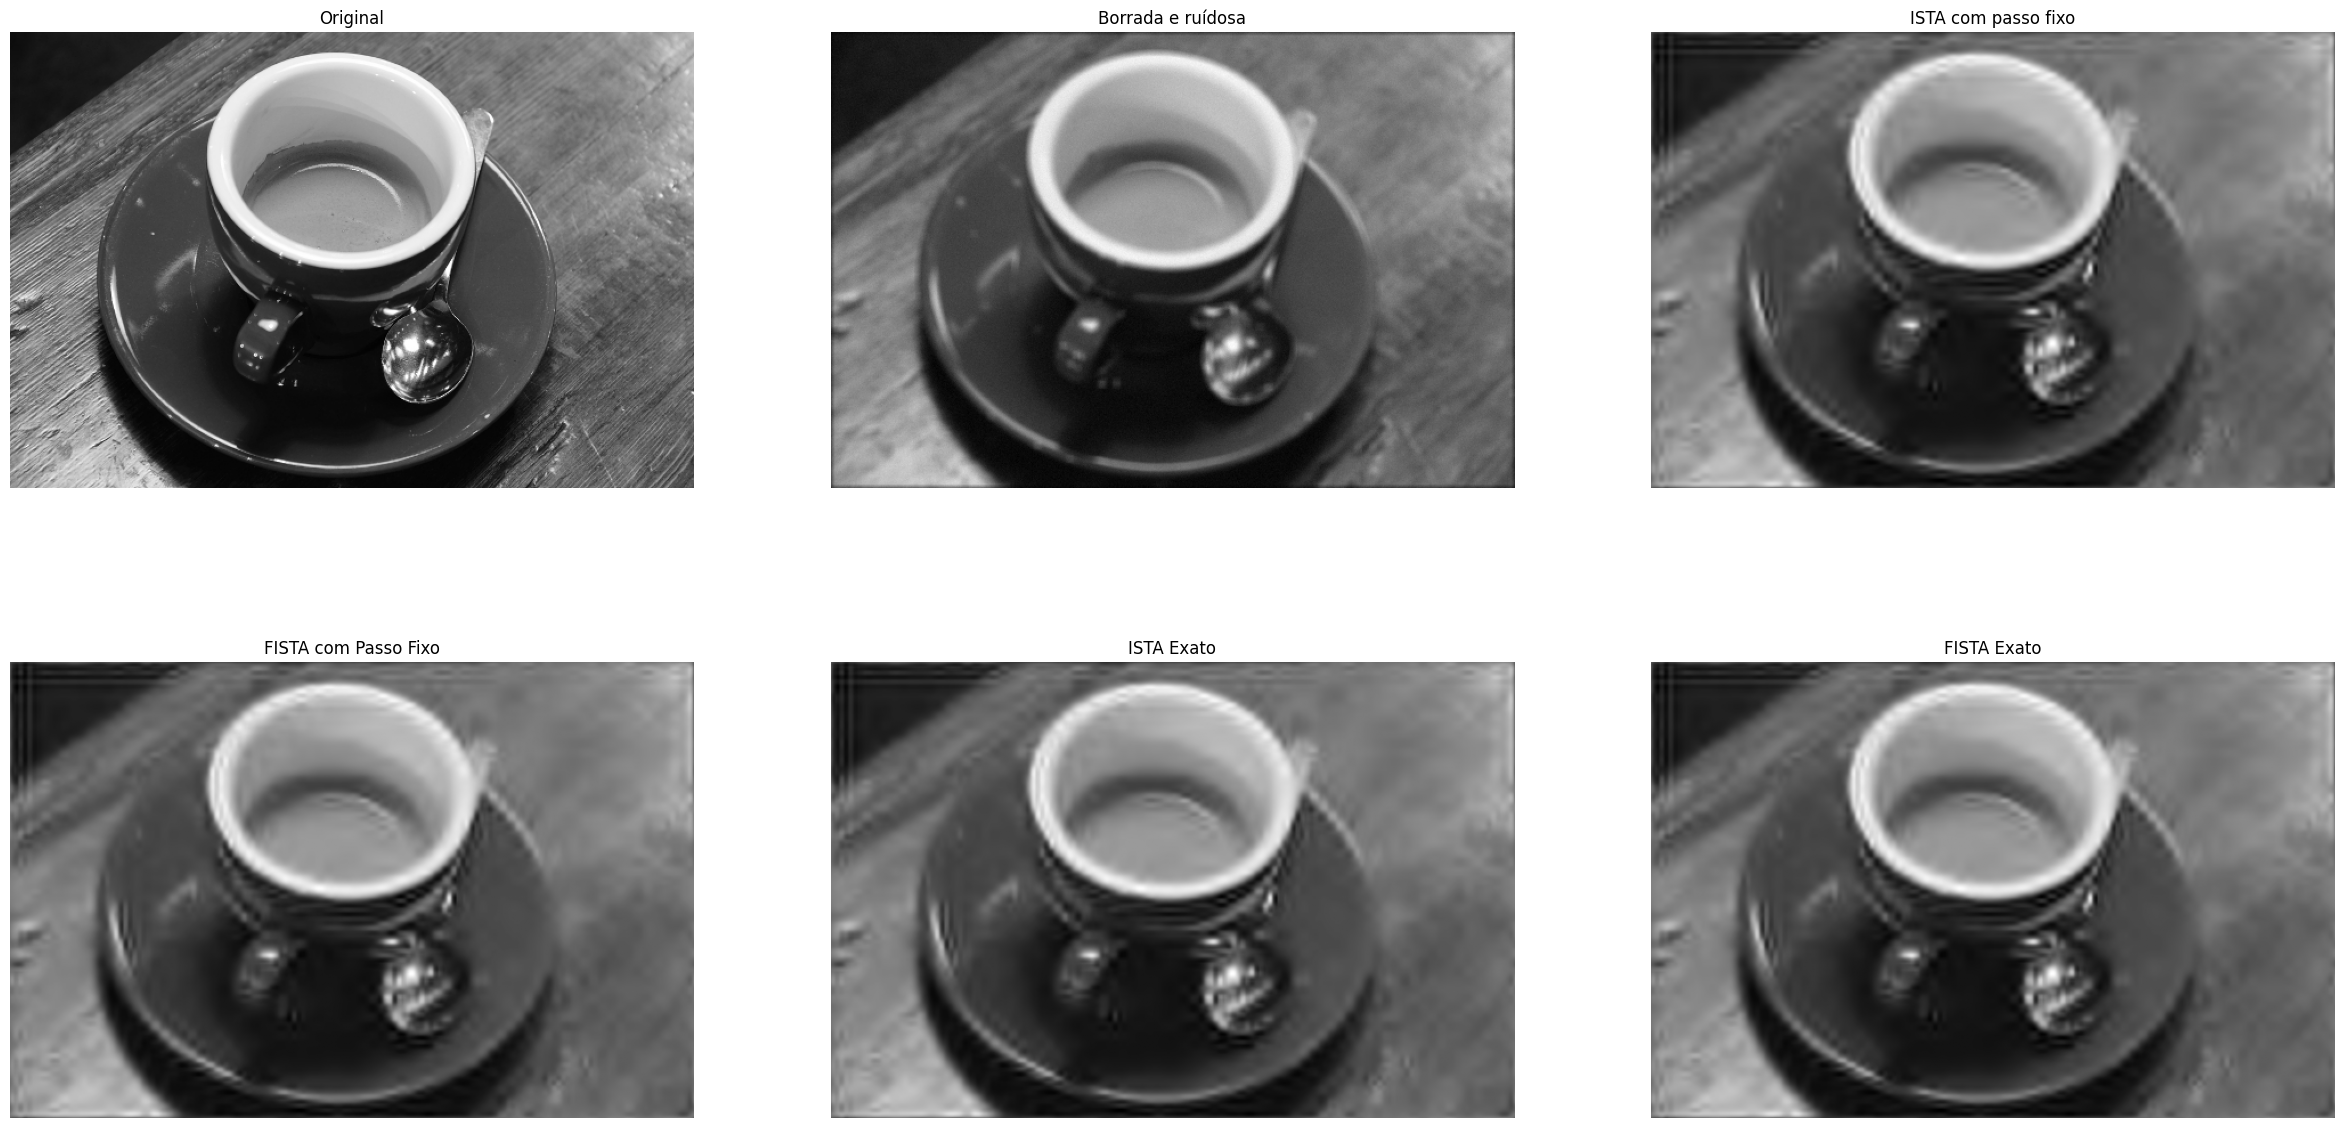

In [ ]:
plt.figure( figsize = ( 30, 15 ) )

plt.subplot( 2, 3, 1 )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Original" )

plt.subplot( 2, 3, 2 )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Borrada e ruídosa" )

plt.subplot( 2, 3, 3 )
plt.imshow( iters_ista_fixo[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "ISTA com passo fixo" )

plt.subplot( 2, 3, 4 )
plt.imshow( iters_fista_fixo[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "FISTA com Passo Fixo" )

plt.subplot( 2, 3, 5 )
plt.imshow( iters_ista_exato[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "ISTA Exato" )

plt.subplot( 2, 3, 6 )
plt.imshow( iters_fista_exato[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "FISTA Exato" )

In [ ]:
F_vals_ista_fixo = [ f( x ) + gamma * g( x, wav ) for x in iters_ista_fixo ]
F_vals_fista_fixo = [ f( x ) + gamma * g( x, wav ) for x in iters_fista_fixo ]
F_vals_ista_exato = [ f( x ) + gamma * g( x, wav ) for x in iters_ista_exato ]
F_vals_fista_exato = [ f( x ) + gamma * g( x, wav ) for x in iters_fista_exato ]


(np.float64(-50.0),
 np.float64(1050.0),
 np.float64(150.00802968187025),
 np.float64(29921.57863249108))

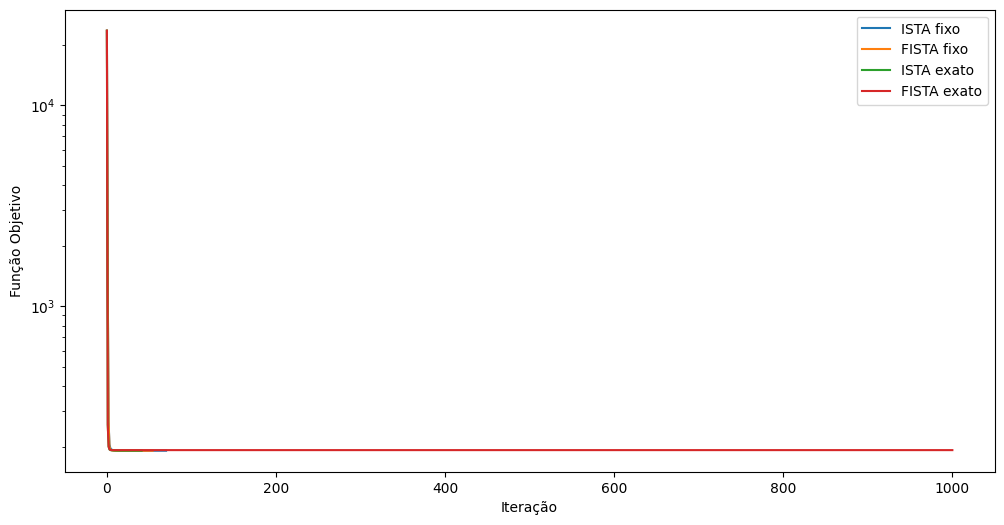

In [ ]:
plt.figure( figsize = ( 12, 6 ) )
plt.semilogy( F_vals_ista_fixo )
plt.semilogy( F_vals_fista_fixo )
plt.semilogy( F_vals_ista_exato )
plt.semilogy( F_vals_fista_exato )
plt.legend( [ "ISTA fixo", "FISTA fixo", "ISTA exato", "FISTA exato" ] )
plt.xlabel( "Iteração" )
plt.ylabel( "Função Objetivo" )
plt.axis( "tight" )

In [ ]:
#numero de iterações
print( "Iterações ISTA fixo: ", len( iters_ista_fixo ) )
print( "Iterações FISTA fixo: ", len( iters_fista_fixo ) )
print( "Iterações ISTA exato: ", len( iters_ista_exato ) )
print( "Iterações ISTA exato: ", len( iters_fista_exato ) )

Iterações ISTA fixo:  71
Iterações FISTA fixo:  55
Iterações ISTA exato:  42
Iterações ISTA exato:  1001


In [ ]:
# valor da função objetivo na ultima iteração
print( "Função objetivo ISTA fixo: ", F_vals_ista_fixo[ -1 ] )
print( "Função objetivo FISTA fixo: ", F_vals_fista_fixo[ -1 ] )
print( "Função objetivo ISTA exato: ", F_vals_ista_exato[ -1 ] )
print( "Função objetivo FISTA exato: ", F_vals_fista_exato[ -1 ] )

Função objetivo ISTA fixo:  190.83458562448328
Função objetivo FISTA fixo:  190.83326014433172
Função objetivo ISTA exato:  190.8814587285683
Função objetivo FISTA exato:  192.15663146136137
